In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from model import CNN
from trainer import ClassifierTrainer

In [2]:
base_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomAutocontrast(),
    *base_transform.transforms
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2)

test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=base_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [01:17<00:00, 2.21MB/s] 


In [11]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

def denormalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

def evaluate_under_augmentation(model, train_transform, device, num=20):
    hard_test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=train_transform)
    hard_test_loader = DataLoader(hard_test_dataset, batch_size=64, shuffle=True)

    half = num // 2
    model.eval()
    with torch.no_grad():
        x, y = next(iter(hard_test_loader))
        logits = model(x[:num].to(device))
        probs = torch.softmax(logits, dim=1).cpu()

    preds = probs.argmax(dim=1)
    correct = preds == y[:num]

    fig, axes = plt.subplots(half, 4, figsize=(16, half * 2))
    fig.suptitle('CIFAR-10 predictions under augmentation', fontsize=13)

    for j in range(half):
        for col_group in range(2):
            i = j + col_group * half
            img = denormalize(x[i]).permute(1, 2, 0)
            color = 'green' if correct[i] else 'red'
            img_col = col_group * 2
            bar_col = col_group * 2 + 1

            true_name = CIFAR10_CLASSES[y[i].item()]
            pred_name = CIFAR10_CLASSES[preds[i].item()]

            # image
            axes[j, img_col].imshow(img)           # no cmap — CIFAR is RGB
            axes[j, img_col].axis('off')
            axes[j, img_col].set_title(f"True: {true_name}\nPred: {pred_name}",
                                        color=color, fontsize=8)

            # bar chart
            bar_colors = ['lightgray'] * 10
            bar_colors[preds[i]] = color
            axes[j, bar_col].bar(range(10), probs[i], color=bar_colors, edgecolor='white')
            axes[j, bar_col].set_xticks(range(10), CIFAR10_CLASSES, rotation=45, ha='right', fontsize=6)
            axes[j, bar_col].set_ylim(0, 1)
            axes[j, bar_col].set_title(f"{probs[i].max():.1%} confidence", fontsize=8)
            axes[j, bar_col].axhline(0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
            axes[j, bar_col].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()
    model.train()

In [12]:
cnn = CNN((3, 64, 64), [16, 32], [128], 10, dropout=0.1)
trainer = ClassifierTrainer(cnn)

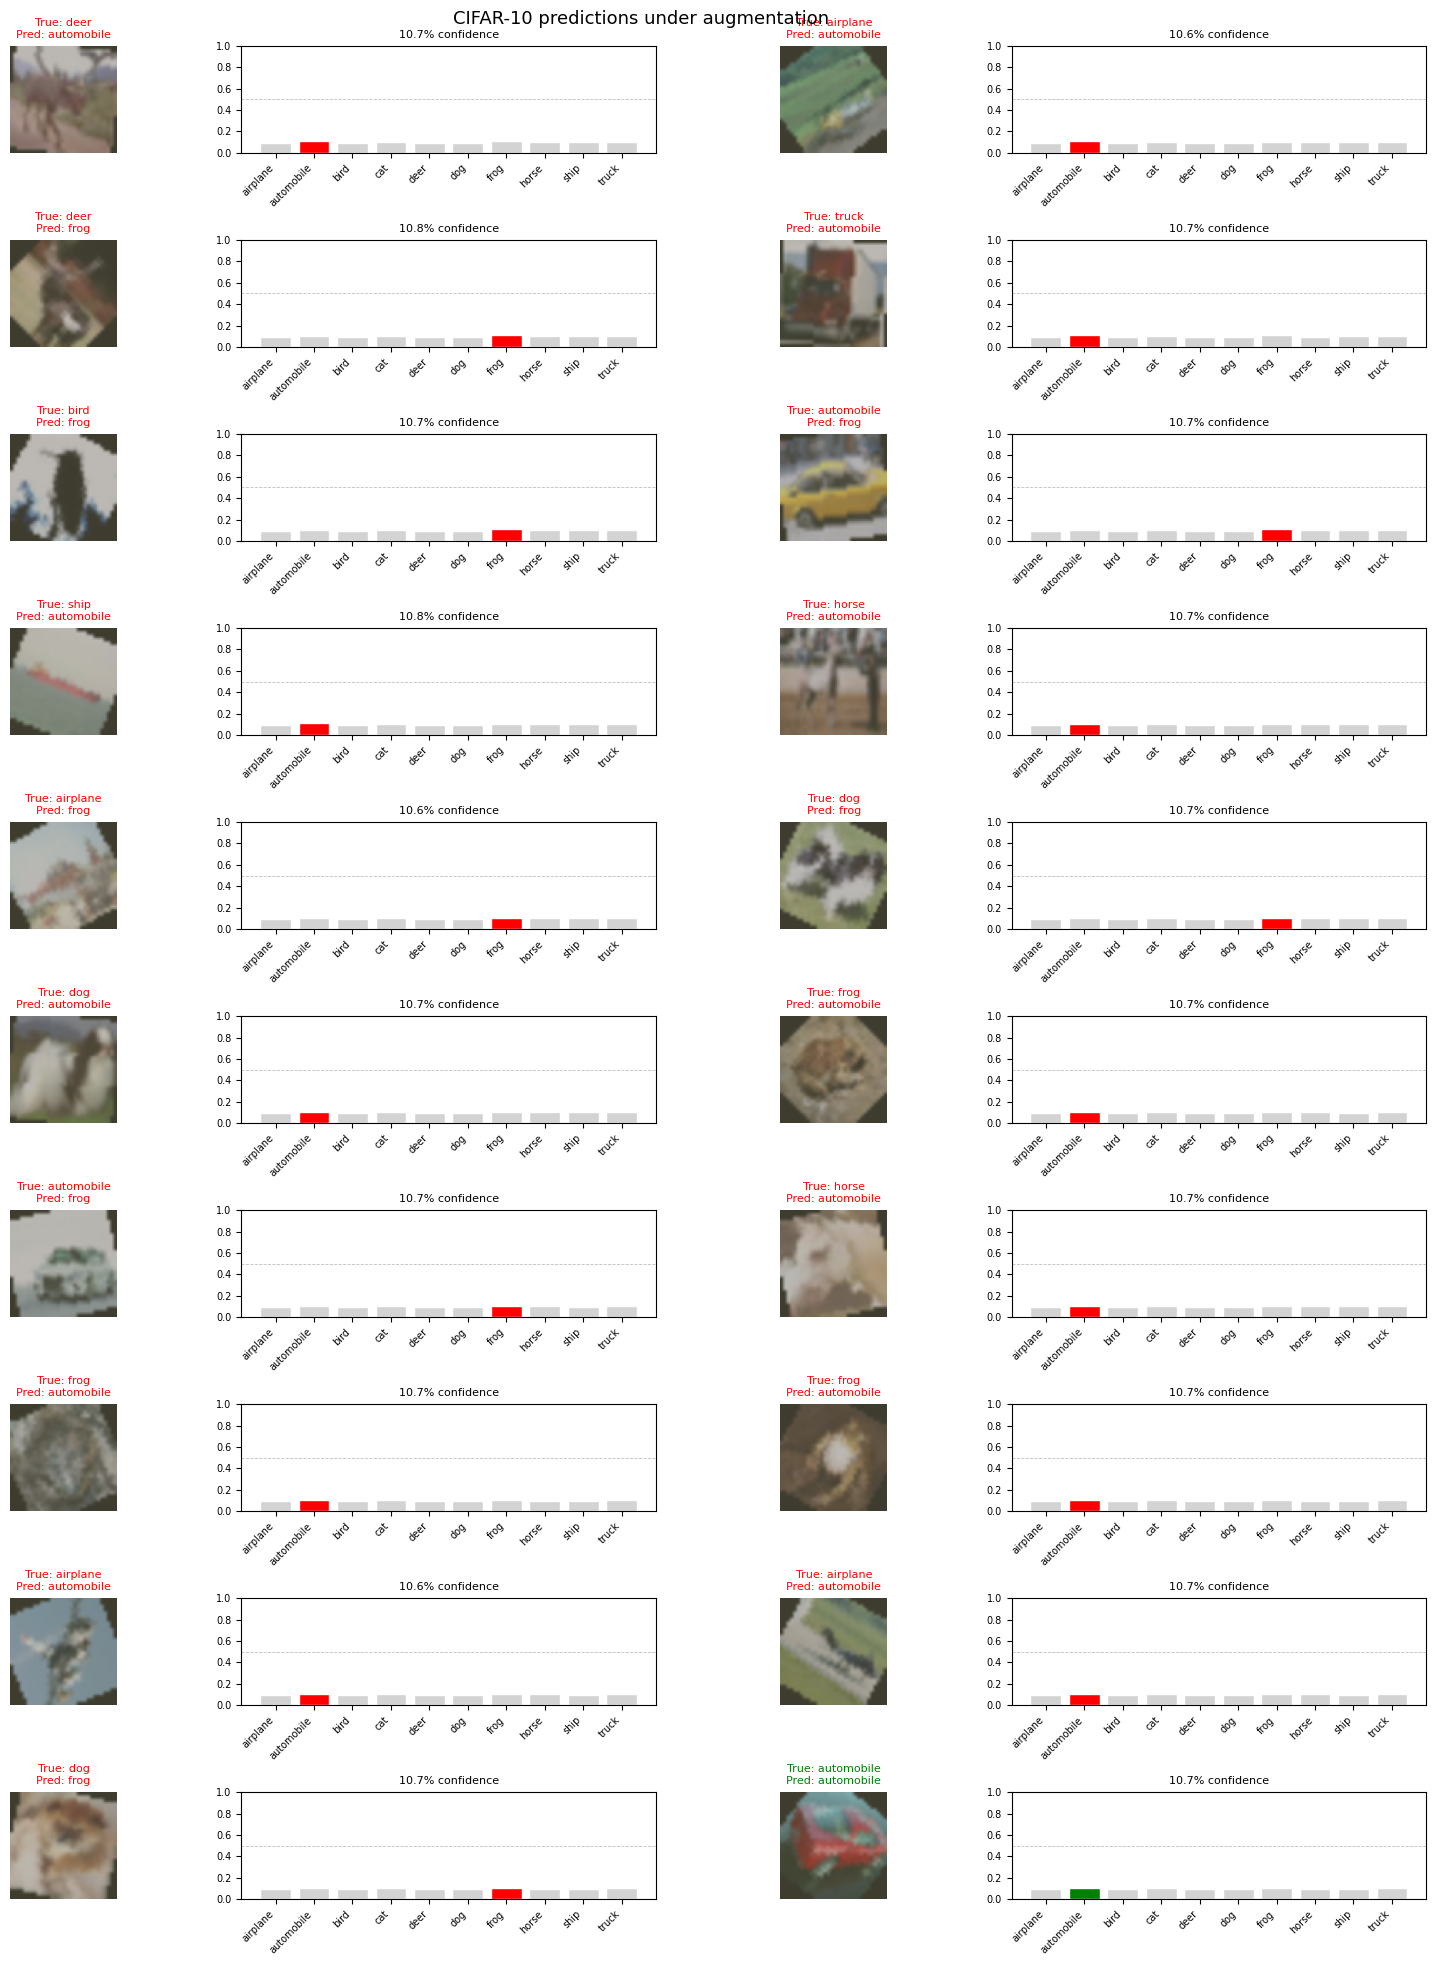

In [15]:
evaluate_under_augmentation(cnn, train_transform, 'cuda')

In [16]:
scores, labels = trainer.train(train_loader, val_loader)

Epoch   0 | Loss: 1.6115 | Statistic: 0.8839


Epoch   1 | Loss: 1.4189 | Statistic: 0.9022


Epoch   2 | Loss: 1.3256 | Statistic: 0.9140


Epoch   3 | Loss: 1.2682 | Statistic: 0.9182


Epoch   4 | Loss: 1.2254 | Statistic: 0.9262


Epoch   5 | Loss: 1.1918 | Statistic: 0.9292


Epoch   6 | Loss: 1.1582 | Statistic: 0.9333


Epoch   7 | Loss: 1.1345 | Statistic: 0.9336


Epoch   8 | Loss: 1.1099 | Statistic: 0.9369


Epoch   9 | Loss: 1.0906 | Statistic: 0.9395
Best Statistic: 0.9395


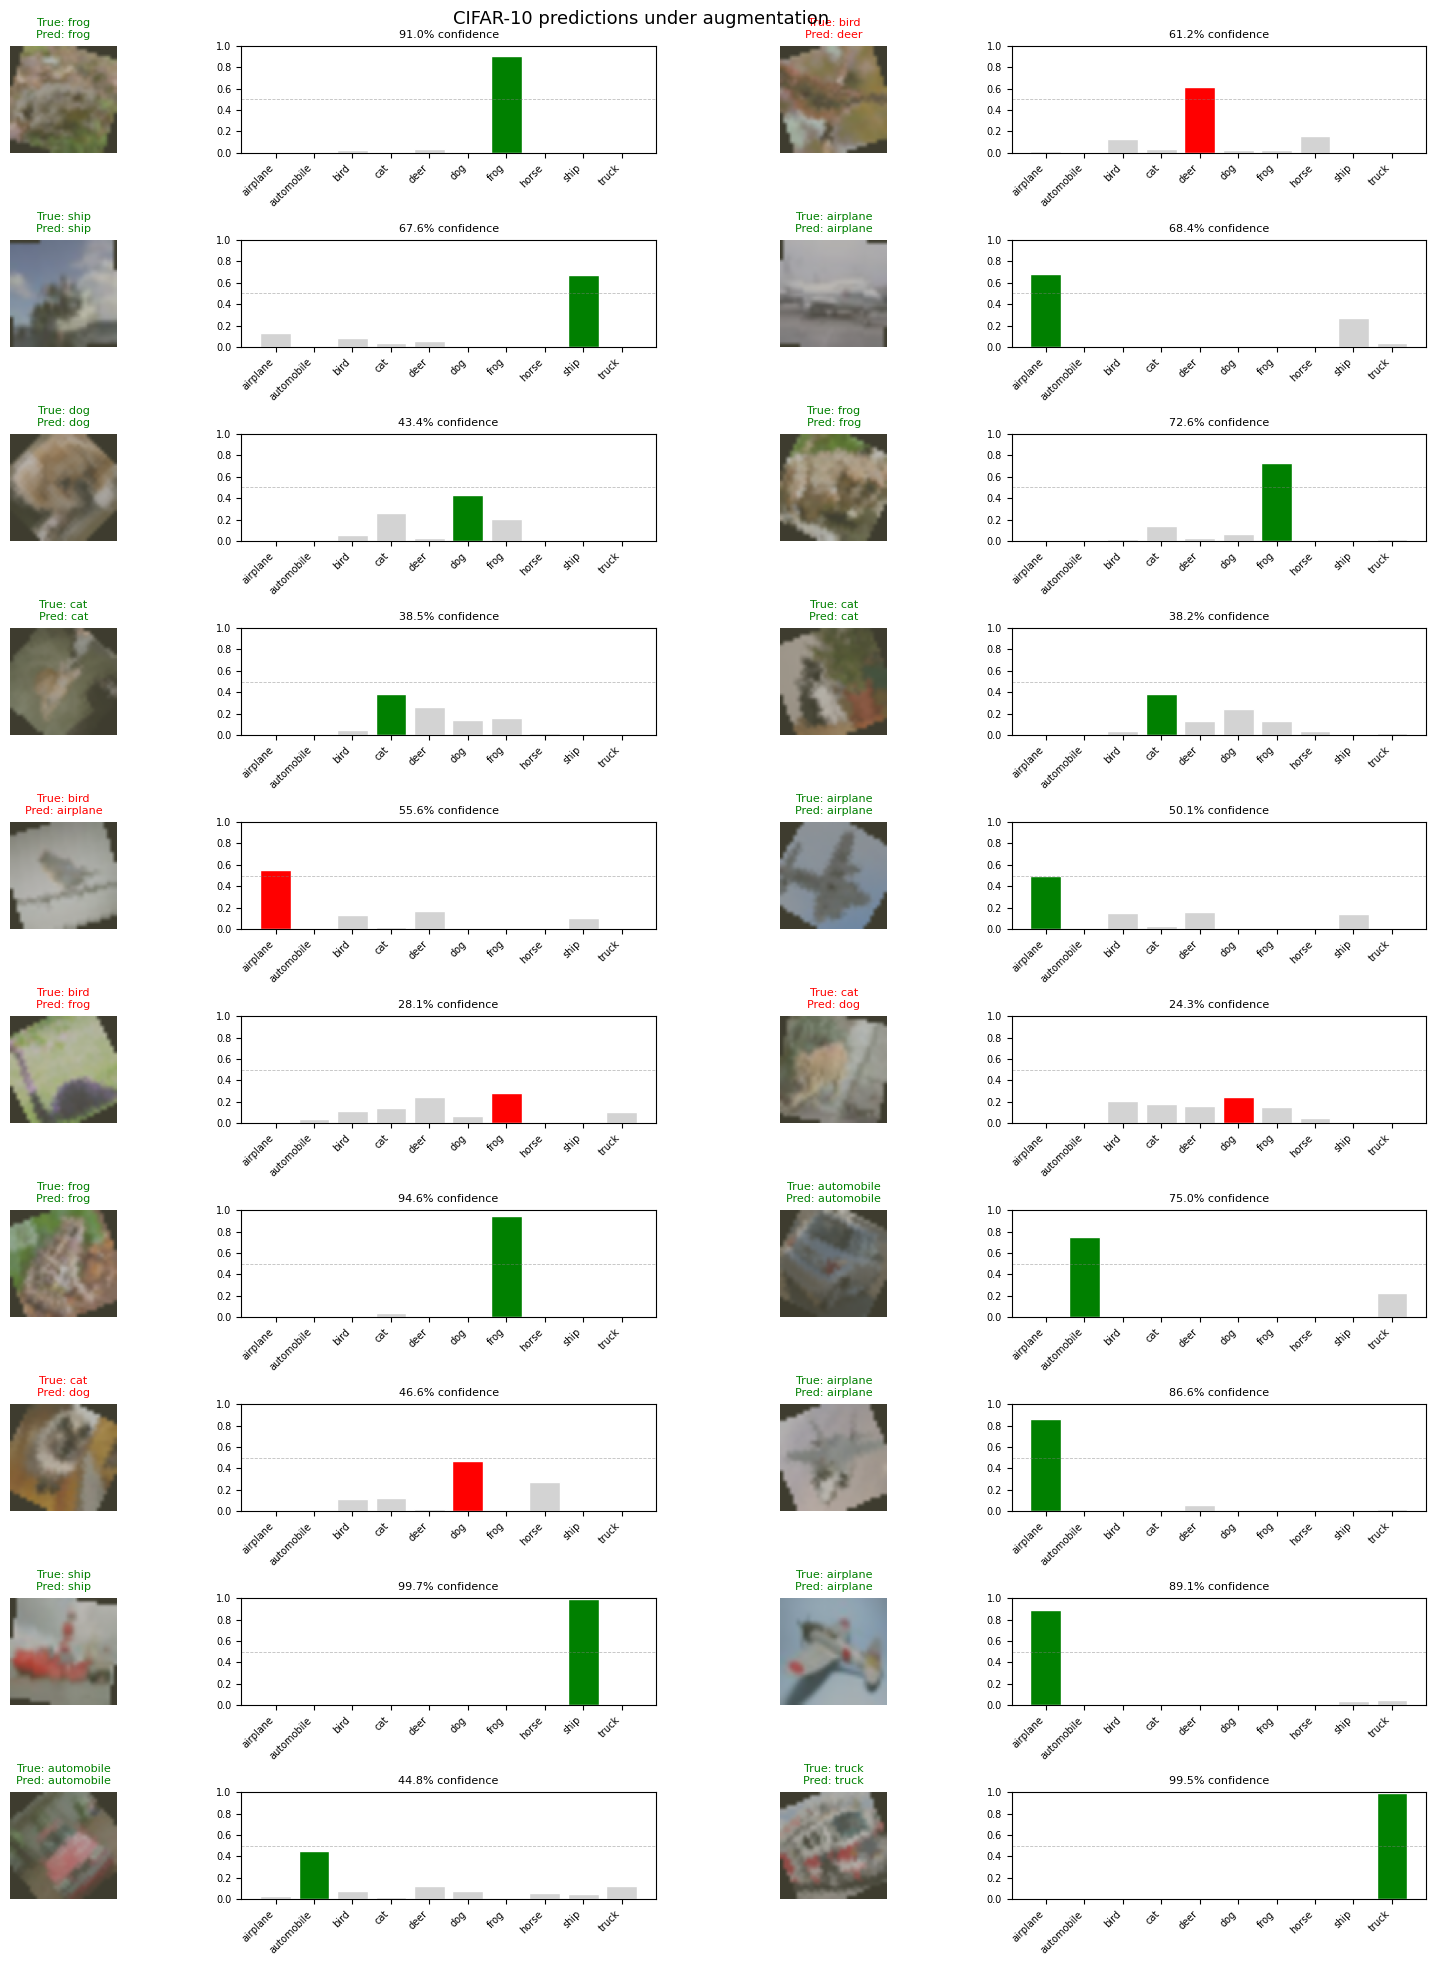

In [17]:
evaluate_under_augmentation(cnn, train_transform, 'cuda')